# 02 — Preprocessing & Cleaning

Turns the raw transactions into **model-ready weekly series** plus a
**product-tier table**. Three sub-steps:

* **2a. Clean** — handle missing target/dates, impossible outliers, returns,
  missing categoricals; add a Monday-anchored `week_start`.
* **2b. Aggregate to weekly** — sum to weekly series per product and per
  product×country, then **reindex to fill zero-demand weeks** (the gaps are the
  intermittent-demand signal models need).
* **2c. Build tiers** — segment products into A / B / C and assign a
  Syntetos–Boylan demand class, so step 4 can route each group to a suitable
  model.

All logic lives in `src/preprocessing.py`; this notebook orchestrates and
inspects. Outputs are written to `data/interim/`, `data/processed/`, and
`outputs/figures/`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader, preprocessing as pp

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
config.ensure_dirs()

## 2a. Clean transactions

Every decision is logged so nothing happens silently — useful for the report's preprocessing section.

In [2]:
df = data_loader.load_raw()
clean, log = pp.clean_transactions(df)

print("Cleaning log:")
for k, v in log.items():
    print(f"  {k:>28}: {v:,}")

Cleaning log:
                       rows_in: 60,670
           dropped_missing_qty: 2
   dropped_impossible_outliers: 1
    dropped_missing_order_date: 139
               returns_flagged: 1
               returns_dropped: 0
     categorical_values_filled: 0
                      rows_out: 60,528


**Notes on the decisions**

* The single ~14.1M-unit row is removed as an *impossible outlier* (cap in
  `config.MAX_PLAUSIBLE_QTY`); most missing-date rows are returns/credits.
* Returns (negative qty) are **kept** as net demand by default
  (`config.RETURNS_POLICY`), with an `is_return` flag.
* Missing categoricals become `"UNKNOWN"`; stray double-spaces are normalised.

In [3]:
clean.head(3)

,Region,Country,Customer Code,Customer ID,Brand Category,Product Range,Sales Channel,Product Code,Order Date,Invoice Date,Invoice No,Sales USD,Sales Qty,Sales KG,Product9,is_return,week_start
0,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-04-01,2022-04-02,INV/34942603,22551.0,4122.0,2943.0,44737-053,False,2022-03-28
1,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-05-18,2022-05-19,INV/23356886,14446.0,2551.0,1905.0,44737-053,False,2022-05-16
2,EUROPE,POLAND,34592,5BX,RETAIL,PREMIUM GRADE,RETAIL,44737-053-R09-SQW-WWJ-0334ST-4.4G-PRM,2022-05-30,2022-05-31,INV/56913810,18650.0,3335.0,2409.0,44737-053,False,2022-05-30


## 2b. Aggregate to weekly series (with zero-week fill)

We build two panels and reindex each series from its first sale to the global last week, filling missing weeks with 0.

In [4]:
weekly_product = pp.build_weekly_product(clean)
weekly_pc = pp.build_weekly_product_country(clean)

print(f"weekly_product rows         : {len(weekly_product):,}")
print(f"weekly_product_country rows : {len(weekly_pc):,}")

# Integrity: reindexing/zero-filling must not change total quantity.
q_clean = clean[config.COL_SALES_QTY].sum()
q_panel = weekly_product[config.COL_SALES_QTY].sum()
print(f"total Sales Qty  clean={q_clean:,.0f}  panel={q_panel:,.0f}  "
      f"-> {'OK' if abs(q_clean - q_panel) < 1 else 'MISMATCH'}")

weekly_product rows         : 1,534,992
weekly_product_country rows : 1,556,688
total Sales Qty  clean=13,876,764  panel=13,876,764  -> OK


In [5]:
# One product's weekly series, showing the zero weeks between sales
example = weekly_product[config.COL_PRODUCT9].iloc[0]
weekly_product[weekly_product[config.COL_PRODUCT9] == example].head(8)

,Product9,week_start,Sales Qty,Sales USD,Sales KG
0,10006-010,2023-03-27,25.0,615.0,10.0
1,10006-010,2023-04-03,0.0,0.0,0.0
2,10006-010,2023-04-10,0.0,0.0,0.0
3,10006-010,2023-04-17,0.0,0.0,0.0
4,10006-010,2023-04-24,0.0,0.0,0.0
5,10006-010,2023-05-01,0.0,0.0,0.0
6,10006-010,2023-05-08,0.0,0.0,0.0
7,10006-010,2023-05-15,0.0,0.0,0.0


## 2c. Product tiers & demand classification

Tier is the routing key for step 4. Tier A = regular (time-series/ML), Tier B = lumpy/intermittent (global model or Croston/TSB), Tier C = sparse/one-off (simple baseline).

In [6]:
tiers = pp.build_product_tiers(weekly_product, clean)

print("Tier counts:")
print(tiers["tier"].value_counts().sort_index().to_string())
print("\nVolume share by tier (%):")
vs = tiers.groupby("tier")["total_qty"].sum()
print((vs / vs.sum() * 100).round(1).sort_index().to_string())
print("\nDemand class (Syntetos-Boylan):")
print(tiers["demand_class"].value_counts().to_string())

Tier counts:
tier
A      428
B     2519
C    10777

Volume share by tier (%):
tier
A    54.6
B    34.8
C    10.5

Demand class (Syntetos-Boylan):
demand_class
intermittent    6523
no_demand       6208
lumpy            985
smooth             8


In [7]:
tiers.head(5)

,Product9,n_weeks_span,n_active_weeks,total_qty,pct_zero_weeks,adi,cv2,n_txns,demand_class,tier,volume_rank
0,68877-087,181,68,381505.0,62.430939,2.661765,0.572032,91,lumpy,A,1
1,53064-028,181,63,327870.0,65.193370,2.873016,0.457038,81,intermittent,A,2
2,14898-083,181,47,285961.0,74.033149,3.851064,0.098621,54,intermittent,A,3
3,81509-047,178,26,281221.0,85.393258,6.846154,0.007405,27,intermittent,A,4
4,60014-011,178,68,248089.0,61.797753,2.617647,0.501188,78,lumpy,A,5


### Diagnostic charts

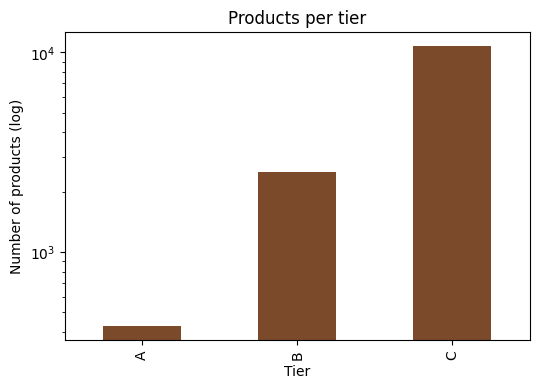

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
tiers["tier"].value_counts().sort_index().plot(kind="bar", color="#7a4a2b", ax=ax)
ax.set_yscale("log"); ax.set_title("Products per tier")
ax.set_xlabel("Tier"); ax.set_ylabel("Number of products (log)")
plt.show()

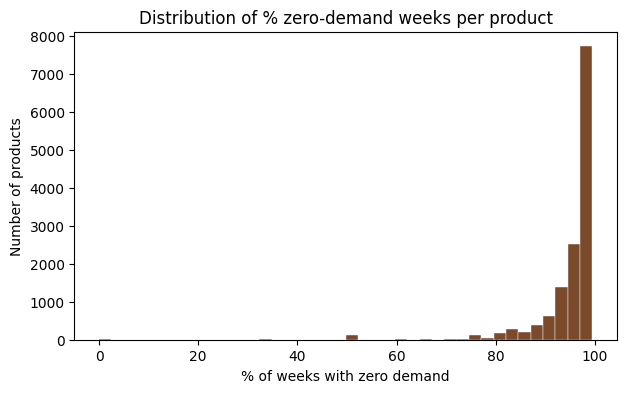

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(tiers["pct_zero_weeks"].dropna(), bins=40,
        color="#7a4a2b", edgecolor="white", linewidth=0.3)
ax.set_title("Distribution of % zero-demand weeks per product")
ax.set_xlabel("% of weeks with zero demand"); ax.set_ylabel("Number of products")
plt.show()

## Save processed files

Writing the two weekly CSVs (~1.5M rows each) can take up to a minute — that's normal.

In [10]:
paths = pp.save_outputs(clean, weekly_product, weekly_pc, tiers)
for name, p in paths.items():
    print(f"{name}: {p}")

cleaned_transactions: /home/claude/cinnamon_sales_forecasting/data/interim/cleaned_transactions.parquet
weekly_product_sales: /home/claude/cinnamon_sales_forecasting/data/processed/weekly_product_sales.csv
weekly_product_country_sales: /home/claude/cinnamon_sales_forecasting/data/processed/weekly_product_country_sales.csv
product_tiers: /home/claude/cinnamon_sales_forecasting/data/processed/product_tiers.csv


## Summary & hand-off to step 3

* Cleaned to ~60.5k transactions; documented every drop/flag.
* Built zero-filled weekly panels: product (~1.53M rows) and product×country
  (~1.56M rows); totals preserved exactly.
* Segmented 13,724 products → **Tier A ≈ 428, Tier B ≈ 2,519, Tier C ≈ 10,777**,
  each with a demand class.

**Next (step 3 — feature engineering):** load `weekly_product_sales.csv` and
`product_tiers.csv`, then build calendar, lag, rolling, and intermittency
features for the Tier A/B series that will be modelled.